# Практична робота 4.3
## Використання методів штучного інтелекту для аналізу даних (регресія)

**Мета роботи:**
- опанувати базові методи регресії для аналізу даних;
- навчитися будувати модель регресії та оцінювати її ефективність засобами Python;
- застосувати реальний набір даних з Kaggle.

### 1. Завантаження даних

Використано набір даних «Diamonds» з Kaggle — характеристики та ціни
53 940 діамантів.

Файл: `../data/diamonds.csv` — 53 940 записів, 10 стовпців.

**Задача регресії:** за характеристиками каменя спрогнозувати його
ціну в доларах (`price`).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження даних
df = pd.read_csv('../data/diamonds.csv')

print('Розмір набору:', df.shape)
print(df.head())

Розмір набору: (53940, 10)
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB
None


### 2. Попередня обробка даних

#### 2.1. Пропущені значення та дублікати

In [3]:
# Перевірка на пропущені значення
print(df.isnull().sum())

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [4]:
# Пропусків формально немає, але діамант не може мати нульовий розмір.
# Нулі в x, y, z - це насправді пропущені виміри.
print('Рядків із нульовим розміром:', ((df[['x', 'y', 'z']] == 0).any(axis=1)).sum())

df[['x', 'y', 'z']] = df[['x', 'y', 'z']].replace(0, np.nan)
print()
print(df[['x', 'y', 'z']].isnull().sum())

Рядків із нульовим розміром: 20

x     8
y     7
z    20
dtype: int64


In [5]:
# Заповнення медіаною
df['x'] = df['x'].fillna(df['x'].median())
df['y'] = df['y'].fillna(df['y'].median())
df['z'] = df['z'].fillna(df['z'].median())

# Видалення дублікатів
print('Рядків до видалення дублікатів:', len(df))
df = df.drop_duplicates().reset_index(drop=True)
print('Рядків після видалення:       ', len(df))
print('Пропущених значень:           ', df.isnull().sum().sum())

Рядків до видалення дублікатів: 53940
Рядків після видалення:        53794
Пропущених значень:            0


#### 2.2. Кодування категоріальних змінних

Усі три категорії впорядковані, тому задаємо порядок явно —
більший код означає кращу якість.

In [6]:
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

df['cut_code'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True).codes
df['color_code'] = pd.Categorical(df['color'], categories=color_order, ordered=True).codes
df['clarity_code'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True).codes

print(df[['cut', 'cut_code', 'color', 'color_code', 'clarity', 'clarity_code']].head())

       cut  cut_code color  color_code clarity  clarity_code
0    Ideal         4     E           5     SI2             1
1  Premium         3     E           5     SI1             2
2     Good         1     E           5     VS1             4
3  Premium         3     I           1     VS2             3
4     Good         1     J           0     SI2             1


#### 2.3. Аналіз кореляцій між числовими змінними

In [7]:
features = ['carat', 'depth', 'table', 'x', 'y', 'z',
            'cut_code', 'color_code', 'clarity_code']

correlation_matrix = df[features + ['price']].corr()
print(correlation_matrix['price'].round(3))

carat           0.922
depth          -0.011
table           0.127
x               0.887
y               0.867
z               0.867
cut_code       -0.052
color_code     -0.172
clarity_code   -0.146
price           1.000
Name: price, dtype: float64


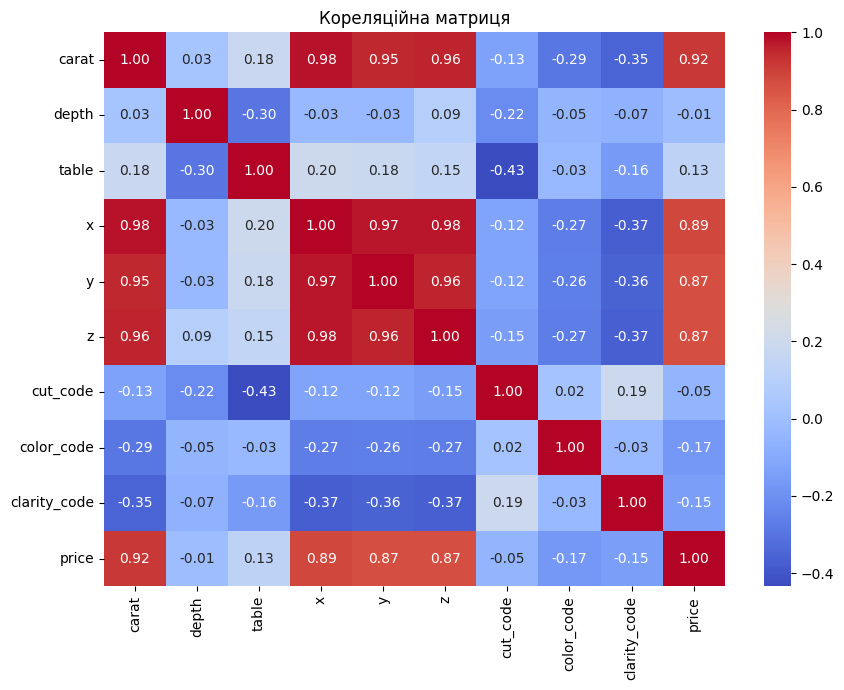

In [8]:
plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Кореляційна матриця')
plt.tight_layout()
plt.show()

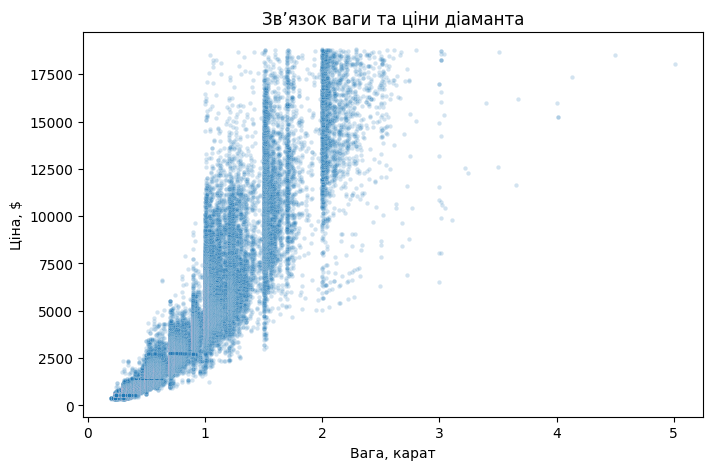

In [9]:
# Як виглядає залежність ціни від ваги
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['carat'], y=df['price'], alpha=0.2, s=10)
plt.title('Звʼязок ваги та ціни діаманта')
plt.xlabel('Вага, карат')
plt.ylabel('Ціна, $')
plt.show()

### 3. Розподіл даних на тренувальний і тестовий набори (80 : 20)

In [10]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Тренувальний набір:', X_train.shape)
print('Тестовий набір:    ', X_test.shape)

Тренувальний набір: (43035, 9)
Тестовий набір:     (10759, 9)


### 4. Побудова моделі лінійної регресії

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Коефіцієнти моделі
print(pd.Series(model.coef_, index=features).round(1))
print()
print('Вільний член:', round(model.intercept_, 1))

carat           10974.8
depth             -39.5
table             -27.6
x                -546.8
y                  98.2
z                -818.3
cut_code          119.1
color_code        322.5
clarity_code      502.1
dtype: float64

Вільний член: 1695.7


In [12]:
# Прогноз на тестовому наборі
predictions = model.predict(X_test)
print(predictions[:10].round(0))

[1441. 4059. 2329. 1764. 6061.  247. -156. 1640. 1508. 4695.]


### 5. Оцінка моделі

In [13]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print('R2   =', round(r2, 3))
print('MSE  =', round(mse, 0))
print('RMSE =', round(mse ** 0.5, 0), '$')

R2   = 0.905
MSE  = 1447354.0
RMSE = 1203.0 $


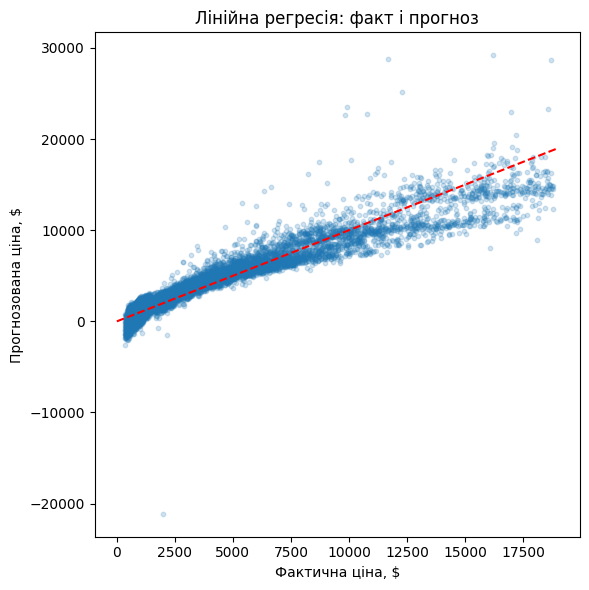

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.2, s=10)
plt.plot([0, 19000], [0, 19000], 'r--')
plt.xlabel('Фактична ціна, $')
plt.ylabel('Прогнозована ціна, $')
plt.title('Лінійна регресія: факт і прогноз')
plt.tight_layout()
plt.show()

### 6. Додаткове завдання: порівняння алгоритмів регресії

Порівняємо лінійну регресію з Ridge, Lasso та деревом рішень
за коефіцієнтом детермінації R² і середньоквадратичною помилкою MSE.

In [15]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

models = {
    'Лінійна регресія': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0, max_iter=10000),
    'Дерево рішень': DecisionTreeRegressor(max_depth=8, random_state=42),
}

results = []
all_predictions = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    all_predictions[name] = p
    results.append({
        'Модель': name,
        'R2': round(r2_score(y_test, p), 3),
        'MSE': round(mean_squared_error(y_test, p), 0),
        'RMSE, $': round(mean_squared_error(y_test, p) ** 0.5, 0),
    })

results_df = pd.DataFrame(results).set_index('Модель')
print(results_df)

                     R2        MSE  RMSE, $
Модель                                     
Лінійна регресія  0.905  1447354.0   1203.0
Ridge             0.905  1445780.0   1202.0
Lasso             0.907  1412788.0   1189.0
Дерево рішень     0.968   485897.0    697.0


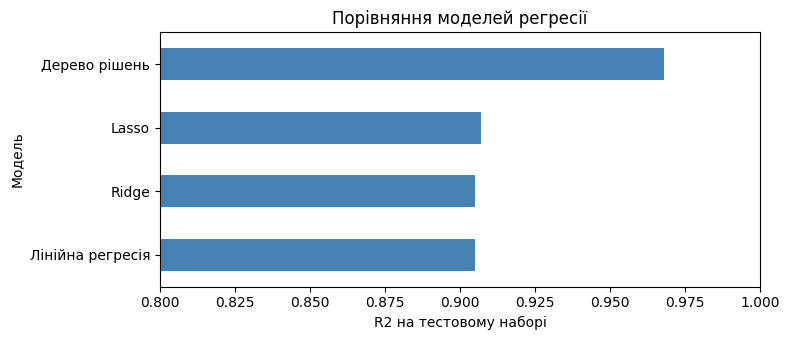

In [16]:
results_df['R2'].plot(kind='barh', color='steelblue', figsize=(8, 3.5))
plt.xlabel('R2 на тестовому наборі')
plt.xlim(0.8, 1.0)
plt.title('Порівняння моделей регресії')
plt.tight_layout()
plt.show()

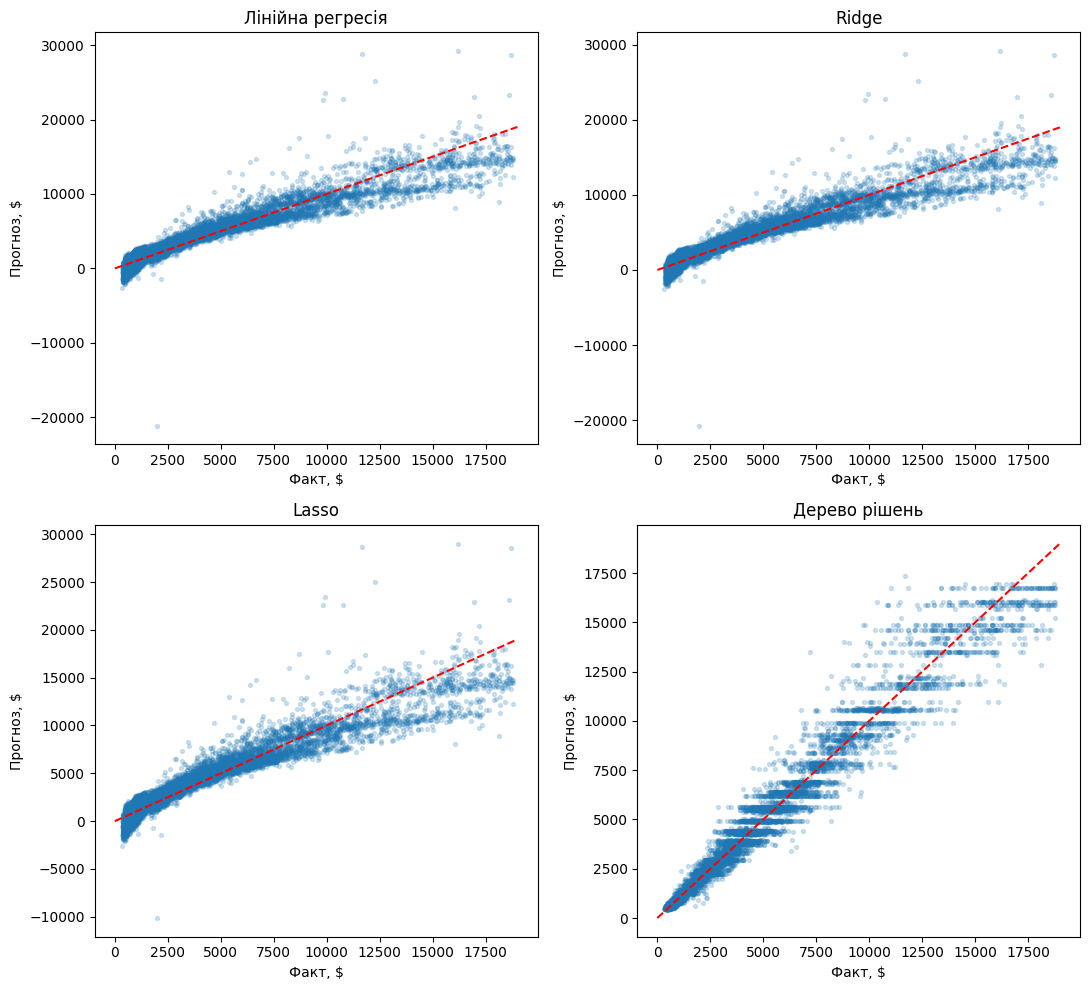

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for ax, (name, p) in zip(axes.ravel(), all_predictions.items()):
    ax.scatter(y_test, p, alpha=0.2, s=8)
    ax.plot([0, 19000], [0, 19000], 'r--')
    ax.set_title(name)
    ax.set_xlabel('Факт, $')
    ax.set_ylabel('Прогноз, $')

plt.tight_layout()
plt.show()

In [18]:
# Які ознаки дерево рішень вважає найважливішими
tree = models['Дерево рішень']
importance = pd.Series(tree.feature_importances_, index=features).sort_values(ascending=False)
print(importance.round(3))

carat           0.647
y               0.258
clarity_code    0.063
color_code      0.028
z               0.002
x               0.001
cut_code        0.000
table           0.000
depth           0.000
dtype: float64


### 7. Звіт

**Використаний підхід.**
Набір даних «Diamonds» з Kaggle — 53 940 записів про продані діаманти.
Задача: за характеристиками каменя спрогнозувати його ціну.

Обробка виконана в такому порядку:

1. `isnull()` показала нуль пропусків, але у 20 записах розміри `x`, `y` або `z`
   дорівнювали нулю. Діамант не може мати нульовий розмір — це прихований
   пропуск, записаний нулем. Такі значення замінено на `NaN` і заповнено медіаною.
2. Видалено 146 повних дублікатів; залишилось 53 794 записи.
3. Три категоріальні змінні закодовано з явним зазначенням порядку,
   щоб більший код означав кращу якість.
4. Сформовано дев'ять ознак: вага, глибина, ширина майданчика, три розміри
   та три оцінки якості.

**Ключові результати.**

| Модель | R² | MSE | RMSE, $ |
|---|---|---|---|
| Лінійна регресія | 0.905 | 1 447 354 | 1 203 |
| Ridge | 0.905 | 1 445 780 | 1 202 |
| Lasso | 0.907 | 1 412 788 | 1 189 |
| **Дерево рішень** (max_depth=8) | **0.968** | **485 897** | **697** |

Ridge і Lasso практично повторюють лінійну регресію: різниця в третьому знаку.
Це очікувано — регуляризація стримує великі коефіцієнти, а тут ознак лише дев'ять
і модель не перенавчається. Lasso трохи кращий, бо занулює внесок `depth`,
який із ціною майже не пов'язаний.

Дерево рішень дає помітно кращий результат: помилка падає майже вдвічі,
з 1 203 $ до 697 $. Причина видна на діаграмі розсіювання — залежність ціни
від ваги **нелінійна**, крива загинається вгору. Лінійна модель проводить
через цю криву пряму й тому систематично помиляється: для дешевих каменів
вона іноді видає від'ємну ціну, а для найдорожчих занижує прогноз.
Дерево ділить простір ознак на діапазони й підбирає свою середню ціну
для кожного, тому кривизна його не турбує.

Найважливіші ознаки для дерева — вага `carat` (0.65) і ширина `y` (0.26),
яка фактично є тією ж вагою, вираженою через розмір. Оцінки якості
додають небагато: чистота 0.06, колір 0.03.

**Висновки.**

1. Ціну діаманта визначає передусім вага. Оцінки якості уточнюють прогноз,
   але самі по собі корелюють із ціною слабко (від -0.05 до -0.17),
   бо кращі за кольором і чистотою камені здебільшого дрібніші.
2. Форма залежності важливіша за вибір лінійної моделі. Перехід
   від лінійної регресії до Ridge чи Lasso не дав нічого, а перехід
   до нелінійної моделі скоротив помилку вдвічі.
3. Метрику варто дивитися разом із графіком «прогноз і факт».
   R² = 0.905 виглядає високим, але графік одразу показує, де модель
   ламається — на дешевих і на найдорожчих каменях.
4. Можливий шлях покращення для лінійної моделі — логарифмувати ціну
   та вагу: це випрямило б залежність і прибрало від'ємні прогнози.